# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

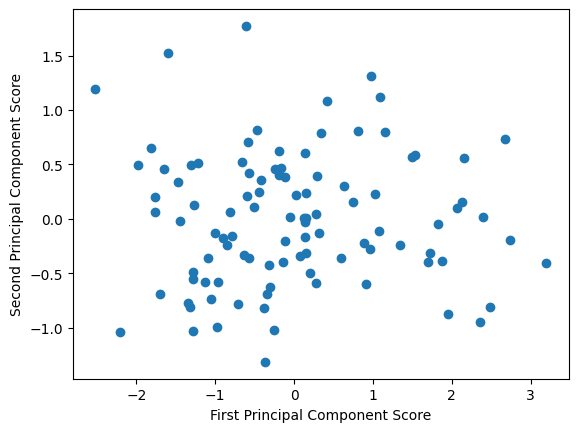

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Based on the graph below and the principal component output, the three outliers have a low first principal component score and a high second principal component score. Additionally, because series 3 has a loading of approximately ~.916 on the first principal component, it suggests that these outliers are mostly affected by their values in series 3. It is harder to describe series 1 and series 2 individually because they appear to be dependent. This is shown by their similar loadings in the first principal component, which changes together in the second principal component. Overall, an advantage of the graph is that it is easier to interpret than the PCA output, and it allows you to visualize the relationships between the first and second principal components as well as identify outliers. A disadvantage, however, is that the graph alone does not show how the principal components were constructed or how much weight each original series contributes to the variation.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [2]:
# Load in dataset
default_credit = pd.read_excel("Default_of_Credit_Card_Clients.xls")
bankruptcy_prediction = pd.read_csv("Taiwanese_Bankruptcy_Prediction.csv")

# changong row 0 to be header and removing original header
default_credit.columns = default_credit.iloc[0]   
default_credit = default_credit[1:]  

# changing all cols from objects to integers
default_credit = default_credit.astype(int)

#changing percent symbol to _pct
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.replace('%', '_pct')

# taking away space in front of each col name
bankruptcy_prediction.columns = bankruptcy_prediction.columns.str.strip()


## Taiwanese Backruptcy Prediction Analysis:

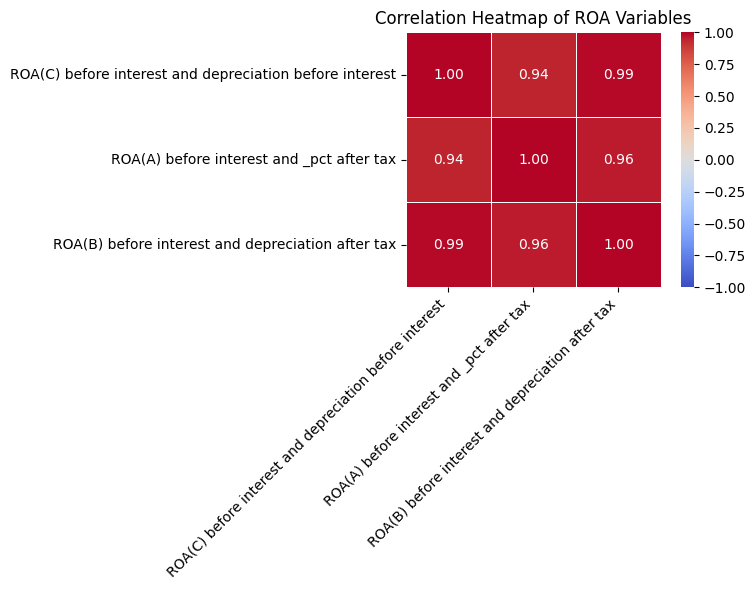

In [ ]:
import seaborn as sns

# correlation heatmap of ROA cols
roa_df = bankruptcy_prediction[[
    'ROA(C) before interest and depreciation before interest',
    'ROA(A) before interest and _pct after tax',
    'ROA(B) before interest and depreciation after tax'
]]

# correlation matrix
corr = roa_df.corr()

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of ROA Variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
# PCA
X = bankruptcy_prediction[
    [
        "Current Liability to Assets",
        "Net Income to Total Assets",
        "Retained Earnings to Total Assets"
    ]
]

pca = decomposition.PCA(n_components=3)
pca.fit(X)

print("Variance ratios:")
print(pca.explained_variance_ratio_)

print("\nPrincipal components:")
print(pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2", "PC3"]
))

Variance ratios:
[0.59463173 0.3663668  0.03900147]

Principal components:
     Current Liability to Assets  Net Income to Total Assets  \
PC1                     0.835936                   -0.475908   
PC2                     0.548818                    0.727780   
PC3                     0.003221                   -0.493810   

     Retained Earnings to Total Assets  
PC1                          -0.273356  
PC2                           0.411261  
PC3                           0.869564  


Conclusions:
Explain what conclusions you would draw from this analysis:  
- Based on the heatmap above, I see that the ROA columns are heavily correlated, with the lowest correlation being 0.94 and the entire heatmap is bright red. This suggest that these columns are possibly redundant and I can drop two of them during preproccessing. Further using PCA, I see that Current Liability to Assets explains most of the variation out of three columns that contain ratios of assests, then followed by Net Income to Total Assets and finally Retained Earnings to Total Assets. This is around what I expected because the ROA had high correlations which I found in hw 6 and currenlt liability indicates short term finances that tend to have more variation.

Do you see any outliers? 
- Based on my current heatmap and PCA, I am not able to identify any clear outliers. However, this suggests that as I continue my analysis, adding a bubble plot would be a good way to visualize the data and better determine if there are any outliers.

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?
- Yes the PCA suggests a way to represent the data using only the first two principal components. This is because around 96 percent of the variation comes from the first two components. This implies that if I dropped the third component, I would still be able to get a good idea of the variation of the Current Liability to Assets, Net Income to Total Assets, and Retained Earnings to Total Assets.

## Default of Credit Card Clients Dataset Analysis:

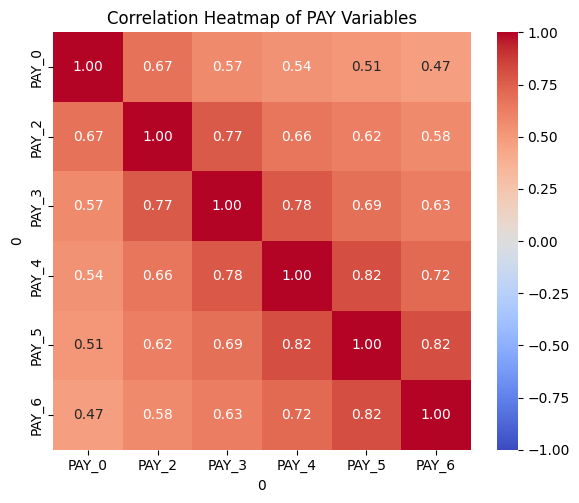

In [ ]:
# correlation heatmap of all PAY cols
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_corr = default_credit[pay_cols].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    pay_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of PAY Variables")
plt.tight_layout()
plt.show()

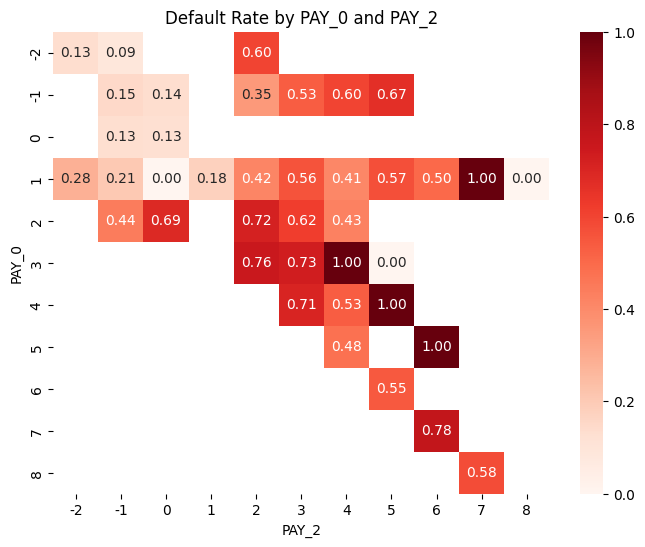

In [ ]:
# correlation heatmap of PAY_0 and PAY_2 only
heatmap_data = (
    default_credit
    .groupby(["PAY_0", "PAY_2"])["default payment next month"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title("Default Rate by PAY_0 and PAY_2")
plt.xlabel("PAY_2")
plt.ylabel("PAY_0")
plt.show()

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? 
- Based on my two heatmaps above, I am able to visualize that those who are typically late on payments, continue the pattern and are repeat offenders. Further in my second heatmap, I shows that when someone makes a late payments, they are very likely to miss a payment by even more time from the first to second payment. This is what I expected just due to owning a credit card and hearing about financial literacy.

Do you see any outliers?
- Yes there are some outliers as those who had had no payment due (-1) in PAY_0, are likely to be late on their payment for PAY_2 by 2 months. Another outlier is those who paid a minimum balance on time in PAY_0, has a very string correlation of 1 with those why were 7 months late on PAY_2.

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?
- I have not done PCA yet on this dataset but will need to in the future to see how much variation each fatures holds.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

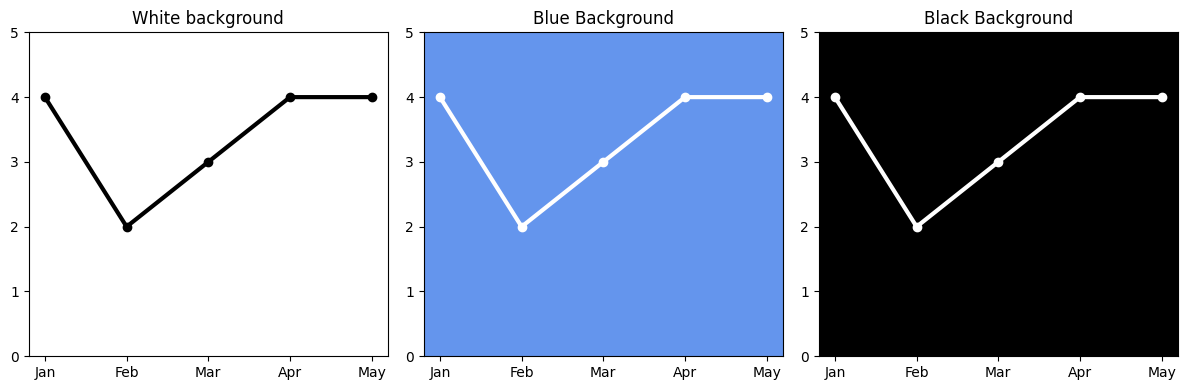

In [36]:
months = ["Jan", "Feb", "Mar", "Apr", "May"]
values = [4, 2, 3, 4, 4]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# White background
ax1.plot(months, values, marker="o", linewidth=3, color="black")
ax1.set_title("White background")
ax1.set_yticks([0,1,2,3,4,5])
ax1.set_xticks(months)

# Blue background
ax2.set_facecolor("cornflowerblue")   
ax2.plot(months, values, marker="o", color="white", linewidth=3)
ax2.set_yticks([0,1,2,3,4,5])
ax2.set_xticks(months)
ax2.set_title("Blue Background")

# Black background
ax3.set_facecolor("black")
ax3.plot(months, values, marker="o", color="white", linewidth=3) 
ax3.set_yticks([0,1,2,3,4,5])
ax3.set_title("Black Background")
ax3.set_xticks(months)


plt.tight_layout()
plt.show()
